# LeNet 실습

## LeNet 모델을 구현한 후 MNIST 데이터셋 분류 실습

### 1. 데이터셋 불러오기
- torchvision에 있는 MNIST 데이터셋을 이용
- LeNet은 보통 32x32 입력을 사용하므로, 28x28 크기의 MNIST 이미지에 가장자리 기준 2픽셀씩 padding을 추가해 32x32로 맞춤

### 2. 모델 생성
- LeNet 모델의 형태인 Conv 계층 2개, Avg_pool 계층 2개와 Fully Connected 3개로 구성
- 활성화 함수로는 Tanh 함수 사용

### 3. 학습 설정
- 최적화 알고리즘으로 Adam을 사용하고, 하이퍼파라미터인 학습률(lr)을 1e-3로 설정
- 손실함수로는 분류 문제에 사용되는 Cross Entropy Loss 사용

### 4. 훈련
- epoch를 50으로 설정하여 모델 학습을 진행
- 각 epoch 마다 training loss를 저장하고 계산하여 학습 경향을 확인

### 5. 모델 평가
- 학습이 끝난 후 model.eval()을 사용하여 평가 모드로 변경
- torch.no_grad()를 사용해 gradient 계산을 비활성화한 뒤, test_loader를 이용해 테스트 정확도를 계산
- 예측 클래스와 실제 정답을 비교해 전체 정확도 측정

### 6. 시각화
- epoch에 따른 training loss를 그래프로 시각화하여 학습이 안정적으로 진행되는지 확인

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
#LeNet 모델을 이용하여 MNIST 데이터셋 훈련

#1. 데이터셋 불러오기
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 이미지 패딩을 위한 변 환 추가
transform = transforms.Compose([
    transforms.Pad(2), # 28x28 이미지를 32x32로 패딩 (각 면에 2픽셀씩 추가)
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

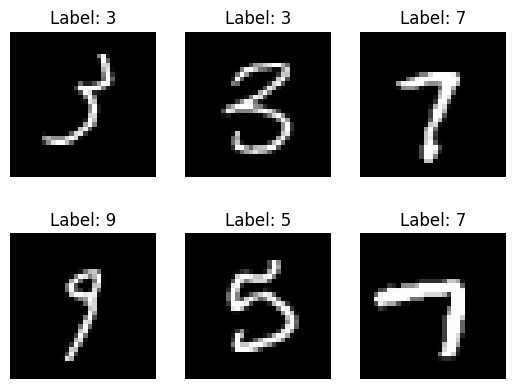

In [22]:
# 출력 데이터 시각화
import matplotlib.pyplot as plt

for images, labels in train_loader:
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i][0], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')

In [23]:
# 2. 모델 생성
import torch.nn as nn
import torch.nn.functional as F

class LeNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 5)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16*5*5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = F.avg_pool2d(F.tanh(self.conv1(x)), 2)
    x = F.avg_pool2d(F.tanh(self.conv2(x)), 2)
    x = torch.flatten(x, 1)
    x = F.tanh(self.fc1(x))
    x = F.tanh(self.fc2(x))
    x = self.fc3(x)

    return x

In [35]:
# 3. 학습 설정
dev_name = 'cuda' if torch.cuda.is_available() else 'cpu'

model = LeNet().to(device=dev_name)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

In [37]:
# 4. 훈련
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
  train_losses = []

  for epoch in range(1, n_epochs+1): # 반복 횟수
    model.train()
    loss_train = 0.0

    for images, labels in train_loader: # 데이터 로더가 만들어준 배치 안에서 데이터셋 순회
      images, labels = images.to(device=dev_name), labels.to(device=dev_name)
      outputs = model(images) # 모델에 배치를 넣어줌

      loss = loss_fn(outputs, labels) # 최소화하려는 손실값 계산
      optimizer.zero_grad() # 이전 기울기값을 초기화
      loss.backward() # 신경망이 학습할 모든 파라미터에 대한 기울기 계산
      optimizer.step() # 모델의 파라미터 값 업데이트

      loss_train += loss.item() # epoch 동안 확인한 손실값을 모두 계산

    avg_train_loss = loss_train / len(train_loader)
    train_losses.append(avg_train_loss)

    if epoch == 1 or epoch % 10 == 0:
      print(f'Epoch {epoch}, Training loss {loss_train/len(train_loader)}')

  return train_losses

train_losses = training_loop(n_epochs=50, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader)

Epoch 1, Training loss 0.003736069907948708
Epoch 10, Training loss 0.0021726543697601895
Epoch 20, Training loss 0.004009504572124009
Epoch 30, Training loss 0.004163167633083888
Epoch 40, Training loss 0.004614310247450353
Epoch 50, Training loss 0.0018265925885783115


In [38]:
# 5. 모델 평가
def evalute_accuracy(model, data_loader):
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad(): # 기울기 계산을 비활성화하여 메모리 사용량을 줄이고 계산 속도 향상
      for images, labels in test_loader:
          images, labels = images.to(device=dev_name), labels.to(device=dev_name)
          outputs = model(images)
          _, predicted = torch.max(outputs, 1) # 가장 높은 확률을 가진 클래스 선택
          total += labels.size(0) # 전체 샘플 수 업데이트
          correct += (predicted == labels).sum().item() # 올바르게 예측된 샘플 수 업데이트

  accuracy = 100 * correct / total
  return accuracy

  print(f'Test Accuracy: {accuracy:.2f}%')

test_accuracy = evalute_accuracy(model, test_loader)

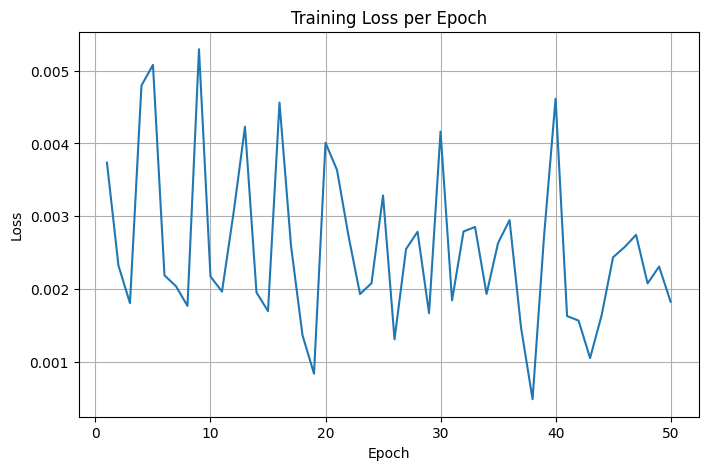

In [39]:
# 훈련 손실 및 정확도 판단
import matplotlib.pyplot as plt

# 손실 그래프
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()